# DATA PRE-PROCESSING in GSE69914 - Advanced study of epigenetic mechanisms in the development of neoplasms 

In this notebook, I will evaluate and define the most appropriate **pre-processing operations**.

### Libraries

In [21]:
!pip install methylprep==1.7.0


<module 'methylprep' from '/usr/local/lib/python3.11/dist-packages/methylprep/__init__.py'>

In [2]:
import methylprep; print(f"✅ methylprep {methylprep.__version__} available")


✅ methylprep 1.7.0 available


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


## 1. Import and Data Structure

The processed dataset is imported from the LZ4-compressed **`.parquet`** file generated in the previous step. The structure is already optimized for analysis.

* **File format:** Columnar **`Parquet`** (LZ4 compression) for fast I/O.
* **Rows:** Samples (one per tissue).
* **Columns:**
    * **`id_tissue`**: Unique sample identifier.
    * **`label`**: Numeric class code (**`Int8`**).
    * **`cg`, `ch`**: Methylation probes (**`Float32`**).


In [4]:
# IMPORT DATA STRUCTURE
PARQUET_PATH = "/kaggle/input/gse69914-parquet/GSE69914.parquet"  # CHANGE HERE!! #
ID_COL = "id_tissue"
LABEL_COL = "label"

# Import dataset
GSE69914 = pl.scan_parquet(PARQUET_PATH)
print("✅ Dataset successfully loaded.")


✅ Dataset successfully loaded.


## 2. Data Validation and Integrity Check
* **Dimensions:** The dataset contains **407 samples × 485,514 CpG loci**, matching the expected layout (samples × features).
* **Data types:** Confirmed schema — `id_tissue: String`, `label: Int8`, `probes: Float32`, ensuring compact storage and numerical precision.
* **β-value range:** All values within `[0.000000, 0.997110]`, correctly bounded in [0, 1].
* **Missing values:** No NaN entries detected across any probe — overall missing rate **0%**.

*The methylation matrix is structurally sound, numerically consistent, and fully complete — no cleaning or imputation required before further analysis.*


In [5]:
# DATA VALIDATION CHECK
# Dimensions (rows × columns)
n_rows = GSE69914.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
n_cols = len(GSE69914.columns)
print(f"- Dimensions: ({n_rows:,}, {n_cols:,}) → samples × CpG loci")

# Data types
schema = GSE69914.schema
id_dtype = schema.get("id_tissue", None)
label_dtype = schema.get("label", None)

# Detect a few probe columns (cg/ch)
probe_cols = [c for c in schema if c.startswith(("cg", "ch"))][:10]
probe_dtypes = {c: schema[c] for c in probe_cols}

print(f"- Data types:")
print(f"  id_tissue: {id_dtype}")
print(f"  label: {label_dtype}")
print(f"  probes (sample): {list(probe_dtypes.values())[:3]} ...")
print("  ✅ Expected types: (Int8, Float32)")

# Value range check (β-values ∈ [0, 1])
# Compute min and max across all probe columns (efficient aggregation)
probe_exprs = [pl.col(c) for c in schema if c.startswith(("cg", "ch"))]
beta_range = GSE69914.select([
    pl.min_horizontal(probe_exprs).alias("beta_min"),
    pl.max_horizontal(probe_exprs).alias("beta_max")
]).collect(streaming=True)

beta_min = float(beta_range["beta_min"][0])
beta_max = float(beta_range["beta_max"][0])

print(f"- β-value range: [{beta_min:.6f}, {beta_max:.6f}]")
if 0 <= beta_min <= 1 and 0 <= beta_max <= 1:
    print("  ✅ All β-values within expected [0, 1] range.")
else:
    print("  ⚠️  Warning: values outside expected range detected.")


- Dimensions: (407, 485,514) → samples × CpG loci
- Data types:
  id_tissue: String
  label: Int8
  probes (sample): [Float32, Float32, Float32] ...
  ✅ Expected types: (Int8, Float32)
- β-value range: [0.000000, 0.997110]
  ✅ All β-values within expected [0, 1] range.


In [6]:
# Select only numeric CpG/CH probe columns (exclude id_tissue, label)
probe_cols = [c for c in GSE69914.columns if c.startswith(("cg", "ch"))]

# Global NaN count across all probes
null_total = (
    GSE69914.select([pl.col(c).null_count().alias(c) for c in probe_cols])
    .select(pl.sum_horizontal(pl.all()).alias("total_null"))
    .collect(streaming=True)["total_null"][0]
)

# Total number of values (for percentage)
total_values = len(probe_cols) * GSE69914.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
missing_rate = null_total / total_values * 100

# Sample check for columns and rows with NaN (to confirm all zero)
col_nulls = (
    GSE69914.select([pl.col(c).null_count().alias(c) for c in probe_cols[:10]])
    .collect(streaming=True)
    .to_dict(as_series=False)
)

print(f"- Total NaN count across all probes: {null_total:,}")
print(f"- Overall missing rate: {missing_rate:.6f}%")

if null_total == 0:
    print("  ✅ No missing entries detected. The methylation matrix is complete.")
else:
    print("  ⚠️ Missing values detected — consider filtering or imputation.")


- Total NaN count across all probes: 0
- Overall missing rate: 0.000000%
  ✅ No missing entries detected. The methylation matrix is complete.


## 3. Correction of Infinium I/II Probe Bias
This approach checks whether the **BMIQ normalization** applied during preprocessing (on the idat file) effectively corrected the design bias between **Infinium Type I** and **Type II** probes, as recommended by Teschendorff *et al.* (2013).  
Using the official Illumina 450K manifest, the β-value distributions are compared across probe types to ensure their alignment after normalization.

✅ *Result:* The correction was successfully applied — Type I and Type II β-value distributions are well aligned, confirming that no additional probe-type bias adjustment is required.


Collected CpGs → Type I: 135,476   Type II: 350,036


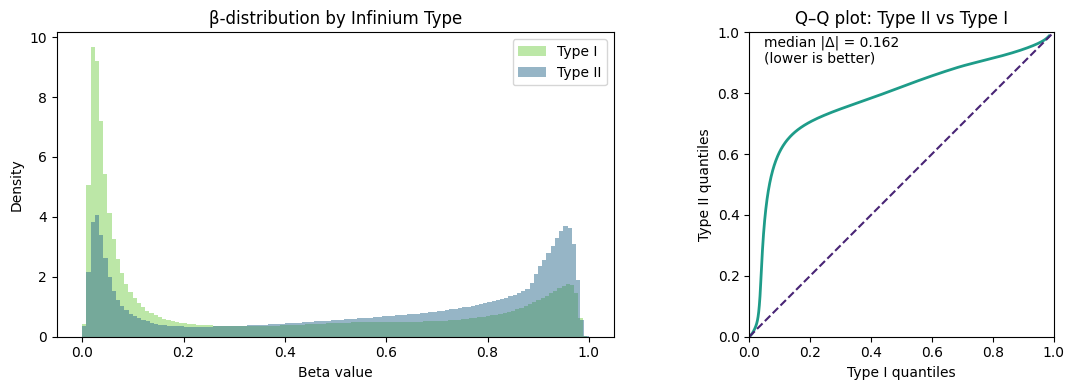

Median absolute deviation from identity (Q–Q): 0.1625 (lower ≈ better alignment)


In [9]:
# TYPE-I / TYPE-II BIAS DIAGNOSTIC 
# Uses ALL CpGs (Type I & Type II) present in your Polars matrix
PROBE_MAP_CSV = "/kaggle/input/annotation-450k-typei-typeii/Annotation_450k_TypeI_TypeII.csv"  

# Load matrix (as LazyFrame) 
LF = GSE69914.lazy() if isinstance(GSE69914, pl.DataFrame) else GSE69914
schema_cols = list(LF.schema.keys())

# Detect CpG columns (wide format: Samples x CpGs, CpGs = columns)
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
if not cpg_cols:
    raise ValueError("No CpG-like columns found (expected columns starting with 'cg' or 'ch').")

# Read probe map & split CpGs by Type 
# Required columns: Name (cg/ch id), Type in {'I','II'}
probe_map = (
    pl.read_csv(PROBE_MAP_CSV)
      .select(
          pl.col("Name").cast(pl.Utf8).str.strip_chars().alias("CpG"),
          pl.col("Type").cast(pl.Utf8).str.strip_chars().alias("Type")
      )
)

typeI_cpgs  = set(probe_map.filter(pl.col("Type") == "I")["CpG"].to_list())  & set(cpg_cols)
typeII_cpgs = set(probe_map.filter(pl.col("Type") == "II")["CpG"].to_list()) & set(cpg_cols)

if not typeI_cpgs or not typeII_cpgs:
    raise ValueError("Type I or Type II CpG sets are empty after intersecting with your matrix columns.")

# Collect all values per Type (no subsampling)
def collect_values_for(cpg_set: Iterable[str]) -> np.ndarray:
    cols = sorted(list(cpg_set))
    # Collect as 2D (Samples x CpGs) then flatten; keep finite values in [0,1]
    M = LF.select(cols).collect(streaming=True).to_numpy()
    vec = M.ravel()
    vec = vec[np.isfinite(vec)]
    return vec[(vec >= 0.0) & (vec <= 1.0)]

vals_I  = collect_values_for(typeI_cpgs)
vals_II = collect_values_for(typeII_cpgs)

print(f"Collected CpGs → Type I: {len(typeI_cpgs):,}   Type II: {len(typeII_cpgs):,}")

# Build figure with 2 panels (density + Q–Q)
cmap = plt.cm.get_cmap("viridis")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# (Left) Overlaid density via normalized histograms
ax[0].hist(vals_I,  bins=120, density=True, alpha=0.50, label="Type I",  color=cmap(0.80))
ax[0].hist(vals_II, bins=120, density=True, alpha=0.50, label="Type II", color=cmap(0.35))
ax[0].set_xlabel("Beta value")
ax[0].set_ylabel("Density")
ax[0].set_title("β-distribution by Infinium Type")
ax[0].legend()

# (Right) Q–Q plot (Type II quantiles vs Type I)
q = np.linspace(0.001, 0.999, 500)           
qI  = np.quantile(vals_I,  q)
qII = np.quantile(vals_II, q)
mad = float(np.median(np.abs(qII - qI)))      # alignment metric

ax[1].plot(qI, qII, lw=2, color=cmap(0.55))
ax[1].plot([0,1], [0,1], ls="--", color=cmap(0.10))
ax[1].set_xlabel("Type I quantiles")
ax[1].set_ylabel("Type II quantiles")
ax[1].set_title("Q–Q plot: Type II vs Type I")
ax[1].set_aspect("equal", adjustable="box")
ax[1].set_xlim(0,1); ax[1].set_ylim(0,1)
ax[1].text(0.05, 0.90, f"median |Δ| = {mad:.3f}\n(lower is better)", transform=ax[1].transAxes)

plt.tight_layout()
plt.savefig("type_bias_density_and_qq.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Median absolute deviation from identity (Q–Q): {mad:.4f} (lower ≈ better alignment)")


## 4. Technical Filtering
### 4.1 Exclusion of technical probe sets
I excluded probes using curated resources that operationalise known technical artefacts.

* **SNP-affected probes:** probes with common variation at the interrogated CpG, at the single-base extension site, or within the probe body.
* **Cross-reactive probes:** probes with off-target/multi-mapping hybridisation.
* **Design-/platform-specific masks:** consolidated `MASK_*` flags for mapping, SNP windows, non-CpG probes, and optional sex-chromosome probes.
* **Naeem hierarchical QC (450K):** discard logic for multi-mapping, repeats, INDEL, and disruptive SNPs.

**Total CpGs removed: 225,426.**

In [5]:
# EXCLUSION OF TECHNICAL PROBE SETS
# Paths
NAEEM_CSV        = "/kaggle/input/filtering-cpg-naeem/filtering_table.csv"                    # Naeem 2014
PIDSLEY_CSV      = "/kaggle/input/filtering-cpg-pidsley/Chen2013_full_blacklist.csv"          # Pidsley 2016 
CHEN_CROSS_CSV   = "/kaggle/input/filtering-cpg-chen-cross-reactive/chen_2013_cross_reactive.csv"  # Chen 2013 
ZHOU_TSV         = "/kaggle/input/filtering-cpg-zhou/EPIC.anno.GRCh38.tsv"                    # Zhou 2016 
MCCARTNEY_CROSS_CPG    = "/kaggle/input/filtering-cpg-mccartney-2/1-s2.0-S221359601630071X-mmc2.txt"     # McCartney 2016 file 2
MCCARTNEY_CROSS_NONCG  = "/kaggle/input/filtering-cpg-mccartney-3/1-s2.0-S221359601630071X-mmc3.txt" # McCartney 2016 file 3

def load_naeem_drop_set(path: str,
                        probe_cands: Iterable[str]=("probe","IlmnID","ID_REF","cg","Name"),
                        flag_cands:  Iterable[str]=("Flag(discard/keep)","flag(discard/keep)","flag","flag_discard_keep")) -> Set[str]:
    """Return probes flagged as 'discard' in Naeem table."""
    df = pl.read_csv(path)
    probe_col = next((c for c in probe_cands if c in df.columns), None)
    flag_col  = next((c for c in df.columns if str(c).lower().strip().startswith("flag")), None) or next((c for c in flag_cands if c in df.columns), None)
    assert probe_col and flag_col, f"Naeem file columns not found. Seen: {df.columns}"
    probes = df[probe_col].cast(pl.Utf8).str.strip_chars()
    flags  = df[flag_col].cast(pl.Utf8).str.to_lowercase()
    return set(probes.filter(flags.str.contains("discard")).to_list())

def load_pidsley_drop_set(path: str, skip_first_lines: int = 1) -> Set[str]:
    """Robust loader for Pidsley."""
    df_comma = pl.read_csv(path, has_header=True, infer_schema_length=10000,
                           separator=",", skip_rows=skip_first_lines)
    try:
        df_tab = pl.read_csv(path, has_header=True, infer_schema_length=10000,
                             separator="\t", skip_rows=skip_first_lines)
    except Exception:
        df_tab = None
    cand = df_tab if (df_tab is not None and df_tab.width > df_comma.width) else df_comma

    cpg_like_cols = [c for c in cand.columns
                     if ("cg" in str(c).lower()) or ("ilmn" in str(c).lower())
                     or ("probe" in str(c).lower()) or ("id" in str(c).lower())]
    if not cpg_like_cols:
        cpg_like_cols = [cand.columns[0]]

    series_list = cand.select(pl.concat_list([pl.col(c).cast(pl.Utf8) for c in cpg_like_cols]).alias("_u")).to_series()
    s = series_list.explode().cast(pl.Utf8).str.strip_chars()
    values = s.to_list()
    return set(x for x in values if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))

def load_firstcol_probe_list(path: str) -> Set[str]:
    """
    Robust 'first column' loader for simple lists.
    Keeps ONLY the first column; returns cg*/ch* IDs.
    """
    def _try_read(sep: str, has_header: bool):
        return pl.read_csv(path, separator=sep, has_header=has_header, infer_schema_length=10000)

    df = None
    for sep in (",", "\t"):
        for hh in (True, False):
            try:
                df = _try_read(sep, hh)
                break
            except Exception:
                df = None
        if df is not None:
            break
    if df is None:  # last resort
        df = pl.read_csv(path, infer_schema_length=10000)

    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()
    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))

def load_chen_crossreactive_firstcol(path: str) -> Set[str]:
    """Chen 2013 cross-reactive list: CSV; keep ONLY the first column with probe IDs."""
    df = pl.read_csv(path, has_header=True, infer_schema_length=10000, separator=",")
    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()
    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))

def zhou_mask_ids(tsv_path: str,
                  id_col_candidates: Iterable[str] = ("probeID","IlmnID","Name")) -> Set[str]:
    """Read only ID + MASK_* columns from Zhou TSV/TSV.GZ and return probes to mask."""
    hdr = pl.read_csv(tsv_path, separator="\t", has_header=True, n_rows=1, ignore_errors=True)
    id_col = next((c for c in id_col_candidates if c in hdr.columns), None)
    assert id_col, f"ID column not found in Zhou TSV. Seen: {hdr.columns}"
    mask_cols = [c for c in hdr.columns if str(c).upper().startswith("MASK")]
    assert mask_cols, "No MASK_* columns found in Zhou TSV."

    df = pl.read_csv(tsv_path, separator="\t", has_header=True, columns=[id_col]+mask_cols,
                     dtypes={id_col: pl.Utf8}, ignore_errors=True)

    truthy = {"true","1","t","yes","y"}
    falsy  = {"false","0","f","no","n",""}
    def mask_to_bool(colname: str) -> pl.Expr:
        s = pl.col(colname).cast(pl.Utf8).str.to_lowercase()
        return (pl.when(s.is_in(list(truthy))).then(True)
                  .when(s.is_in(list(falsy))).then(False)
                  .otherwise(False)
                  .alias(colname))
    df_norm = df.select([pl.col(id_col).cast(pl.Utf8).str.strip_chars().alias(id_col)] + [mask_to_bool(c) for c in mask_cols])

    mask_any = pl.any_horizontal([pl.col(c) for c in mask_cols])
    bad = df_norm.filter(mask_any)[id_col].to_list()
    return set(bad)

# Dataset layout
lf = GSE69914.lazy() if isinstance(GSE69914, pl.DataFrame) else GSE69914 
schema_cols = list(lf.schema.keys())
n_cols_before = len(schema_cols)
n_rows_before = lf.select(pl.len()).collect().item()

id_col_candidates = ("IlmnID","probeID","ID_REF","CpG","cg_id","Name")
id_col = next((c for c in id_col_candidates if c in schema_cols), None)

if id_col:
    present_cpgs = set(
        lf.select(pl.col(id_col).cast(pl.Utf8).str.strip_chars().alias("_id")).unique()
          .collect().get_column("_id").to_list()
    )
    layout = "rows"
else:
    cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
    present_cpgs = set(cpg_cols)
    layout = "cols"

# Load lists + intersect with present CpGs
print("Loading technical filter lists...")
S_naeem_all     = load_naeem_drop_set(NAEEM_CSV)
S_pidsley_all   = load_pidsley_drop_set(PIDSLEY_CSV)
S_zhou_all      = zhou_mask_ids(ZHOU_TSV)
S_chenx_all     = load_chen_crossreactive_firstcol(CHEN_CROSS_CSV)

# McCartney = union(File2 CpG-cross, File3 non-CpG-cross) 
S_mccartney2_all = load_firstcol_probe_list(MCCARTNEY_CROSS_CPG)
S_mccartney3_all = load_firstcol_probe_list(MCCARTNEY_CROSS_NONCG)
S_mccartney_all  = S_mccartney2_all | S_mccartney3_all

S_naeem     = S_naeem_all     & present_cpgs
S_pidsley   = S_pidsley_all   & present_cpgs
S_zhou      = S_zhou_all      & present_cpgs
S_chenx     = S_chenx_all     & present_cpgs
S_mccartney = S_mccartney_all & present_cpgs

print(f"• Naeem 2014 (discard flag)                    → in dataset: {len(S_naeem):,}     / total in list: {len(S_naeem_all):,}")
print(f"• Pidsley/Chen (full blacklist)                → in dataset: {len(S_pidsley):,}   / total in list: {len(S_pidsley_all):,}")
print(f"• Zhou 2016 (MASK_*)                           → in dataset: {len(S_zhou):,}      / total in list: {len(S_zhou_all):,}")
print(f"• Chen 2013 (cross-reactive)                   → in dataset: {len(S_chenx):,}     / total in list: {len(S_chenx_all):,}")
print(f"• McCartney 2016 (cross-hyb CpG + non-CpG)     → in dataset: {len(S_mccartney):,} / total in list: {len(S_mccartney_all):,}")

# Union to remove + apply filter 
removed_cpgs = S_naeem | S_pidsley | S_zhou | S_chenx | S_mccartney

if layout == "rows":
    lf_filt = lf.filter(~pl.col(id_col).is_in(list(removed_cpgs)))
else:
    keep_cols = [c for c in schema_cols if c not in removed_cpgs]
    lf_filt = lf.select(keep_cols)

pl.DataFrame({"removed_cpg": sorted(removed_cpgs)}).write_csv("removed_cpgs.csv")
n_cols_after = len(lf_filt.schema)
n_rows_after = lf_filt.select(pl.len()).collect().item()

print("\nSummary:")
print(f"  • Samples × Probes (before): {n_rows_before} × {n_cols_before}")
print(f"  • Samples × Probes (after):  {n_rows_after} × {n_cols_after}")
print(f"  • Total removed CpGs:        {len(removed_cpgs):,}")
print(f"    - from Naeem:      {len(S_naeem):,}")
print(f"    - from Pidsley:    {len(S_pidsley):,}")
print(f"    - from Zhou:       {len(S_zhou):,}")
print(f"    - from Chen-X:     {len(S_chenx):,}")
print(f"    - from McCartney:  {len(S_mccartney):,}")

# Overlaps exclusive partitions
lists: Dict[str, Set[str]] = {
    "Naeem": S_naeem,
    "Pidsley": S_pidsley,
    "Zhou": S_zhou,
    "ChenX": S_chenx,
    "McCartney": S_mccartney,
}
keys = list(lists.keys())

exclusive_counts: Dict[Tuple[str,...], int] = {}
for r in range(1, len(keys)+1):
    for combo in combinations(keys, r):
        inter = set.intersection(*(lists[k] for k in combo))
        others = set().union(*(lists[k] for k in keys if k not in combo))
        excl = inter - others
        exclusive_counts[combo] = len(excl)

print("\nExclusive overlaps (present CpGs only):")
for r in range(1, len(keys)+1):
    for combo in combinations(keys, r):
        lbl = " ∩ ".join(combo)
        print(f"  • {lbl}: {exclusive_counts[combo]:,}")

# save detailed per-CpG source log (5 flags + source count)
pl.DataFrame(
    [{"CpG_ID": cg,
      "From_Naeem":     int(cg in S_naeem),
      "From_Pidsley":   int(cg in S_pidsley),
      "From_Zhou":      int(cg in S_zhou),
      "From_ChenX":     int(cg in S_chenx),
      "From_McCartney": int(cg in S_mccartney)} for cg in removed_cpgs]
).with_columns(
    (pl.col("From_Naeem")+pl.col("From_Pidsley")+pl.col("From_Zhou")+pl.col("From_ChenX")+pl.col("From_McCartney")).alias("Source_Count")
).sort(["Source_Count","CpG_ID"], descending=[True, False])\
 .write_csv("removed_cpgs_log.csv")

print("\nArtifacts:")
print("  • saved removed list → removed_cpgs.csv")
print("  • saved detailed log → removed_cpgs_log.csv")

# Optionally persist the filtered dataset:
GSE69914_filt = lf_filt


Loading technical filter lists...
• Naeem 2014 (discard flag)                    → in dataset: 190,672     / total in list: 190,672
• Pidsley/Chen (full blacklist)                → in dataset: 39,737   / total in list: 67,030
• Zhou 2016 (MASK_*)                           → in dataset: 96,541      / total in list: 193,182
• Chen 2013 (cross-reactive)                   → in dataset: 29,233     / total in list: 29,233
• McCartney 2016 (cross-hyb CpG + non-CpG)     → in dataset: 28,582 / total in list: 44,208

Summary:
  • Samples × Probes (before): 407 × 485514
  • Samples × Probes (after):  407 × 260088
  • Total removed CpGs:        225,426
    - from Naeem:      190,672
    - from Pidsley:    39,737
    - from Zhou:       96,541
    - from Chen-X:     29,233
    - from McCartney:  28,582

Exclusive overlaps (present CpGs only):
  • Naeem: 116,068
  • Pidsley: 987
  • Zhou: 21,787
  • ChenX: 556
  • McCartney: 734
  • Naeem ∩ Pidsley: 1,063
  • Naeem ∩ Zhou: 44,424
  • Naeem ∩ ChenX: 1

In [6]:
n_rows = GSE69914_filt.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
n_cols = len(GSE69914_filt.columns)
print(f"- Dimensions: ({n_rows:,}, {n_cols:,}) → samples × CpG loci")


- Dimensions: (407, 260,088) → samples × CpG loci


### 4.2 Annotation-based filtering
A cross-check was performed using the official *Illumina HumanMethylation450 v1.2 Manifest* ([download link](https://emea.support.illumina.com/array/array_kits/infinium_humanmethylation450_beadchip_kit/downloads.html)) to retain only valid and well-characterized probes.
This step ensures consistency with the manufacturer’s reference mapping (hg19) and removes:

* Probes with invalid or missing chromosome (`CHR`);
* Undefined or non-positive genomic position (`MAPINFO`);
* Duplicated probe identifiers (`IlmnID`);
* Non-CpG-targeting probes (`ch*`).

This guarantees that the retained loci align with Illumina’s validated design and prevents coordinate mismatches in downstream analyses.

**Result:** 875 non-CpG probes were removed, leaving **407 samples × 259,213 CpGs**.


In [7]:
# ANNOTATION-BASED FILTERING USING Illumina Manifest
lf0 = GSE69914_filt.lazy() if isinstance(GSE69914_filt, pl.DataFrame) else GSE69914_filt

# Illumina official manifest CSV 
# HumanMethylation450 v1.2 Manifest File
MANIFEST_CSV = "/kaggle/input/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"  

# Find the [Assay] header block in the manifest and read the table 
def _find_assay_skiprows(csv_path: str) -> int:
    """
    Return the number of rows to skip so that the next row is the header line starting with IlmnID,Name,...
    Manifest structure:
      [Heading]
      ... metadata ...
      [Assay]
      IlmnID,Name,AddressA_ID,...
      ...
    """
    skip = 0
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as fh:
        lines = fh.readlines()
    # find the line index of "[Assay]" and then header is the next line
    for i, line in enumerate(lines):
        if line.strip().startswith("[Assay]"):
            skip = i + 1
            break
    return skip

skip_rows = _find_assay_skiprows(MANIFEST_CSV)

# read manifest assay table with Polars
man = pl.read_csv(
    MANIFEST_CSV,
    skip_rows=skip_rows,
    has_header=True,
    infer_schema_length=2000,
    separator=",",
    ignore_errors=True
)

# Normalize/validate key columns from the manifest 
# Column name candidates (Illumina standard):
ID_COL_CANDS   = ("IlmnID", "Name")               # probe ID (IlmnID primary; Name also has cg/ch IDs)
CHR_COL_CANDS  = ("CHR", "Chromosome")
POS_COL_CANDS  = ("MAPINFO", "Coordinate_36", "Coordinate_37", "Coordinate_38")  # MAPINFO is hg19

id_col  = next((c for c in ID_COL_CANDS  if c in man.columns), None)
name_col = "Name" if "Name" in man.columns else None
chr_col = next((c for c in CHR_COL_CANDS if c in man.columns), None)
pos_col = next((c for c in POS_COL_CANDS if c in man.columns), None)
assert id_col is not None, f"Cannot find IlmnID/Name in manifest. Seen: {man.columns}"

man = man.with_columns(
    pl.col(id_col).cast(pl.Utf8).str.strip_chars().alias("_ID")
)

# If Name exists, keep it to detect non-CpG ("ch..."). Otherwise infer from _ID if it already starts with cg/ch.
if name_col:
    man = man.with_columns(pl.col(name_col).cast(pl.Utf8).str.strip_chars().alias("_NAME"))

# CHR validity
if chr_col:
    man = man.with_columns(
        pl.col(chr_col).cast(pl.Utf8).str.strip_chars()
          .str.replace(r"(?i)^chr", "", literal=False)
          .str.to_uppercase().alias("_CHR")
    )
    valid_chr = set([str(i) for i in range(1,23)] + ["X","Y"])
    man = man.with_columns(pl.col("_CHR").is_in(valid_chr).alias("_ok_chr"))
else:
    man = man.with_columns(pl.lit(True).alias("_ok_chr"))

# POS validity
if pos_col:
    man = man.with_columns(pl.col(pos_col).cast(pl.Int64, strict=False).alias("_POS"))
    man = man.with_columns((pl.col("_POS") > 0).fill_null(False).alias("_ok_pos"))
else:
    man = man.with_columns(pl.lit(True).alias("_ok_pos"))

# Detect non-CpG probes (no dedicated column in the manifest; use cg/ch convention):
# - CpG-targeting probes typically have IDs like cg######## (NAME starts with "cg")
# - non-CpG-targeting probes are typically "ch########"
# Prefer NAME if present (more explicit); fallback to _ID.
if name_col:
    man = man.with_columns(
        pl.col("_NAME").str.to_lowercase().str.starts_with("ch").fill_null(False).alias("_is_nonCG")
    )
else:
    man = man.with_columns(
        pl.col("_ID").str.to_lowercase().str.starts_with("ch").fill_null(False).alias("_is_nonCG")
    )

# Duplicate mapping / duplicate IDs in manifest (should be rare, but we guard)
dup_ids = set(
    man.group_by("_ID").len().filter(pl.col("len") > 1).get_column("_ID").to_list()
)
man = man.with_columns(pl.col("_ID").is_in(list(dup_ids)).alias("_is_duplicate"))

# Build fast lookup maps
man_one = man.unique(subset=["_ID"], keep="first")

id_list  = man_one.get_column("_ID").to_list()
ok_chr   = man_one.get_column("_ok_chr").to_list()
ok_pos   = man_one.get_column("_ok_pos").to_list()
is_dup   = man_one.get_column("_is_duplicate").to_list()
is_nonCG = man_one.get_column("_is_nonCG").to_list()

flag_map: Dict[str, Dict[str, bool]] = {
    i: {"ok_chr": c, "ok_pos": p, "dup": d, "nonCG": n}
    for i, c, p, d, n in zip(id_list, ok_chr, ok_pos, is_dup, is_nonCG)
}

# Detect dataset layout (CpG rows vs columns) and collect present CpGs 
schema_cols: Sequence[str] = list(lf0.schema.keys())
id_col_in_df = next((c for c in ("IlmnID","probeID","ID_REF","CpG","cg_id","Name") if c in schema_cols), None)

if id_col_in_df:
    present = set(
        lf0.select(pl.col(id_col_in_df).cast(pl.Utf8).str.strip_chars().alias("_id")).unique()
          .collect().get_column("_id").to_list()
    )
    layout = "rows"
    meta_cols = [c for c in schema_cols if c != id_col_in_df]
else:
    present = set([c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))])
    layout = "cols"
    meta_cols = [c for c in schema_cols if c not in present]

# Classify and filter with reasons
removed_rows: List[Dict[str, str]] = []
keep_ids: Set[str] = set()

for cg in present:
    f = flag_map.get(cg)
    if f is None:
        removed_rows.append({"CpG_ID": cg, "Reason": "not_in_manifest"})
        continue
    reasons = []
    if not f["ok_chr"]:
        reasons.append("invalid_chromosome")
    if not f["ok_pos"]:
        reasons.append("invalid_position")
    if f["dup"]:
        reasons.append("ambiguous_mapping")
    if f["nonCG"]:
        reasons.append("non_CpG_probe")
    if reasons:
        removed_rows.append({"CpG_ID": cg, "Reason": ";".join(reasons)})
    else:
        keep_ids.add(cg)

removed_ids = set(r["CpG_ID"] for r in removed_rows)

# Apply to my matrix
if layout == "rows":
    lf_annot = lf0.filter(~pl.col(id_col_in_df).cast(pl.Utf8).str.strip_chars().is_in(list(removed_ids)))
else:
    keep_cols = meta_cols + sorted(list(keep_ids if keep_ids else (present - removed_ids)))
    lf_annot = lf0.select(keep_cols)

# Artifacts & summary 
rem_df = pl.DataFrame(removed_rows)
if rem_df.height == 0:
    print("Manifest cross-check: no probes removed (0).")
else:
    rem_df.write_csv("removed_cpgs_manifest.csv")
    cnt = (
        rem_df
        .with_columns(pl.col("Reason").cast(pl.Utf8).str.split(";").alias("parts"))
        .explode("parts")
        .with_columns(pl.col("parts").cast(pl.Utf8).str.strip_chars().alias("Reason_norm"))
        .filter(pl.col("Reason_norm").is_not_null() & (pl.col("Reason_norm") != ""))
        .group_by("Reason_norm").len()
        .rename({"len": "Count", "Reason_norm": "Reason"})
        .sort("Count", descending=True)
    )
    cnt.write_csv("removed_cpgs_manifest_reasons_counts.csv")
    print("Reasons saved → removed_cpgs_manifest.csv / removed_cpgs_manifest_reasons_counts.csv")
    print(cnt)

n_before = len(present)
n_removed = rem_df.height
print(f"CpGs present at input: {n_before:,}")
print(f"Removed by manifest:  {n_removed:,}")
print(f"Remaining (estimated): {n_before - n_removed:,}")

# Final object for downstream
GSE69914_annot_filt = lf_annot


Reasons saved → removed_cpgs_manifest.csv / removed_cpgs_manifest_reasons_counts.csv
shape: (1, 2)
┌───────────────┬───────┐
│ Reason        ┆ Count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ non_CpG_probe ┆ 875   │
└───────────────┴───────┘
CpGs present at input: 260,086
Removed by manifest:  875
Remaining (estimated): 259,211


In [8]:
n_rows = GSE69914_annot_filt.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
n_cols = len(GSE69914_annot_filt.columns)
print(f"- Dimensions: ({n_rows:,}, {n_cols:,}) → samples × CpG loci")


- Dimensions: (407, 259,213) → samples × CpG loci


## 5. Filtering of Invariant CpGs

This approach evaluates methylation variability across CpGs using the **inter-decile beta-range** ($r_{\beta} = P90 - P10$), following the empirically driven approach proposed by *Edgar et al.* (2017).  
The goal is to identify **non-variable loci** that carry no discriminatory signal and may inflate statistical noise.  

Three thresholds are tested ($r_{\beta} < 0.01$, $0.02$, $0.05$) to study their impact on probe removal, both:
- on the **entire dataset** (Normal, Adjacent, Tumor);
- and on a **restricted subset** including only Normal and Adjacent tissues.

🧩 *Decision pending:* the optimal cutoff (e.g., $r_{\beta} \ge 0.01$) and whether to apply it globally or only within subsets will be determined after evaluating downstream performance.


CONFIG: Analyzing labels=None, Study thresholds=[0.01, 0.02, 0.05]
Found 259,211 CpG columns to analyze.
Starting beta-range (P90 - P10) calculation in 1 pass...
Beta-range calculation complete.

=== Preliminary Study (beta-range < threshold) ===
  Threshold t = 0.01: Removes      1,782 / 259,211 CpGs (  0.7%)
  Threshold t = 0.02: Removes     28,569 / 259,211 CpGs ( 11.0%)
  Threshold t = 0.05: Removes     79,433 / 259,211 CpGs ( 30.6%)

Applied threshold t = 0.01 → Removed 1,782 CpGs; Kept 257,429 CpGs.
Saved: cpg_removed_nonvariable.csv
Generating plot...


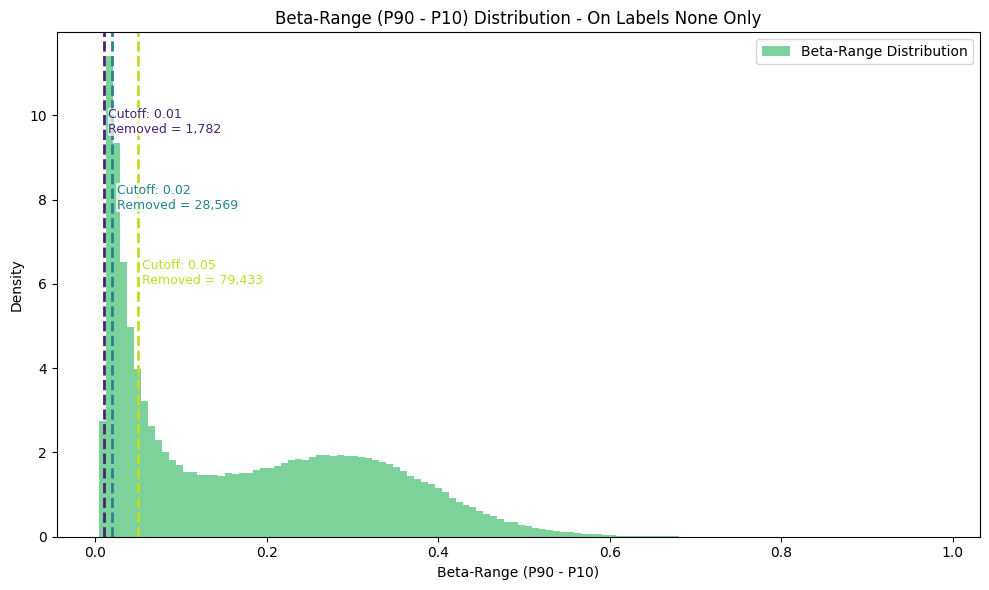


Summary: 259,211 CpGs analyzed on ALL samples. Final threshold applied = 0.01.
Variable 'GSE69914_varFilt' (LazyFrame) is ready for the next step.


In [14]:
# === Optimized Non-variable CpG filtering (Polars, wide matrix, fast) ===
#
# GOALS (as requested):
# 1. Run the analysis (study, filter, plot) only on the subset of labels [0, 1, 3].
# 2. Calculate the beta-range (P90 - P10) for each CpG in *one single pass*.
# 3. Study the thresholds [0.01, 0.02, 0.05] to justify the choice.
# 4. Apply the chosen filter (e.g., 0.01) to create the new filtered LazyFrame.
# 5. Create a final plot with the histogram and all 3 threshold annotations.

# ---------------- CONFIGURATION (as requested) ---------------------------
LABEL_COL       = "label"             # Column used for the subset
LABEL_FILTER    = None #[0, 1, 3]           # <- ACTIVE: Analysis only on these samples
THRESHOLDS      = [0.01, 0.02, 0.05]  # <- ACTIVE: For the study and plot
THRESH_TO_USE   = 0.01                # <- ACTIVE: Chosen threshold for the final filter
HIST_BINS       = 120
print(f"CONFIG: Analyzing labels={LABEL_FILTER}, Study thresholds={THRESHOLDS}")

# ---------------- 0) Prepare LazyFrame + Apply Label Subset ------------------
# Assume 'GSE69914_annot_filt' exists from a previous cell
LF0 = GSE69914_annot_filt.lazy() if isinstance(GSE69914_annot_filt, pl.DataFrame) else GSE69914_annot_filt
schema_cols = list(LF0.schema.keys())

# *** CRITICAL OPTIMIZATION: Filter *before* computing ***
# Apply the label filter (if the column exists)
if (LABEL_COL in schema_cols) and (LABEL_FILTER is not None):
    LF = LF0.filter(pl.col(LABEL_COL).is_in(LABEL_FILTER))
    print(f"Filter applied: {len(LABEL_FILTER)} labels selected.")
else:
    LF = LF0
    if LABEL_FILTER is None:
        print("WARNING: No label filter applied. Analysis on the full dataset will be extremely SLOW.")
    else:
        print("No label filter applied (column not found).")

# Identify CpG columns and metadata columns (e.g., id, label)
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
meta_cols = [c for c in schema_cols if c not in cpg_cols]
if not cpg_cols:
    raise ValueError("No CpG columns found (expected 'cg' or 'ch' prefixes).")

print(f"Found {len(cpg_cols):,} CpG columns to analyze.")

# ---------------- 1) Calculate Beta-Range (P90-P10) - OPTIMIZED (1 pass) --
# This calculation now runs ONLY on the filtered rows (e.g., labels 0,1,3)
# and will be very fast.
print("Starting beta-range (P90 - P10) calculation in 1 pass...")

# Build one expression for *each* CpG column
# This calculates (q90 - q10) per column, all in parallel
beta_range_exprs = [
    (pl.col(c).quantile(0.90) - pl.col(c).quantile(0.10)).alias(c)
    for c in cpg_cols
]

# Execute the single (and now fast) computation
# The result is a DataFrame (1 row x N CpGs) with the beta-range values
try:
    beta_range_df = LF.select(beta_range_exprs).collect(streaming=True)
except Exception:
    beta_range_df = LF.select(beta_range_exprs).collect()

# Convert to a NumPy array for fast stats and plotting
# The column order is preserved
beta_range = beta_range_df.to_numpy()[0, :]

print("Beta-range calculation complete.")

# ---------------- 2) Preliminary Study (Justification) -------------------
print("\n=== Preliminary Study (beta-range < threshold) ===")
n_total = beta_range.size
removed_counts = {} # Dictionary to save counts for the plot

for t in THRESHOLDS:
    cnt = int(np.sum(beta_range < t))
    removed_counts[t] = cnt
    print(f"  Threshold t = {t:.2f}: Removes {cnt:10,} / {n_total:,} CpGs ({cnt/n_total:6.1%})")

# ---------------- 3) Apply the Chosen Threshold ------------------------------
mask_keep = beta_range >= THRESH_TO_USE
keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
remove_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}

# Build the final filtered LazyFrame (keeps meta_cols + filtered CpGs)
LF_var = LF.select(meta_cols + sorted(list(keep_cpgs)))

# Save artifacts
pl.DataFrame({"CpG_removed": sorted(remove_cpgs)}).write_csv("cpg_removed_nonvariable.csv")
print(f"\nApplied threshold t = {THRESH_TO_USE:.2f} → Removed {len(remove_cpgs):,} CpGs; Kept {len(keep_cpgs):,} CpGs.")
print("Saved: cpg_removed_nonvariable.csv")

# Expose the filtered LazyFrame for downstream steps
GSE69914_varFilt = LF_var

# ---------------- 4) Final Plot (as requested) -----------------------
print("Generating plot...")
cmap = plt.cm.get_cmap("viridis")
hist_color = cmap(0.70)

plt.figure(figsize=(10, 6)) # Made slightly larger for labels
plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7, color=hist_color, label="Beta-Range Distribution")

# Vertical lines for the 3 thresholds
y_top, y_idx = plt.ylim()[1], 0.85
colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

for t, color in zip(THRESHOLDS, colors):
    removed = removed_counts[t]
    
    # Label as requested
    label_text = f"Cutoff: {t:.2f}\nRemoved = {removed:,}"
    
    plt.axvline(t, linestyle="--", linewidth=2, color=color)
    plt.text(t + 0.005, y_top * y_idx, label_text, fontsize=9, color=color,
             ha='left', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2))
    y_idx -= 0.15 # Move the next label down

plt.title(f"Beta-Range (P90 - P10) Distribution - On Labels {LABEL_FILTER} Only")
plt.xlabel("Beta-Range (P90 - P10)")
plt.ylabel("Density")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("beta_range_distribution_study.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------- 5) Summary ---------------------------------------------
subset_info = f"on labels {LABEL_FILTER}" if (LABEL_FILTER is not None and LABEL_COL in schema_cols) else "on ALL samples"
print(f"\nSummary: {n_total:,} CpGs analyzed {subset_info}. Final threshold applied = {THRESH_TO_USE:.2f}.")
print("Variable 'GSE69914_varFilt' (LazyFrame) is ready for the next step.")

CONFIG: Analyzing labels=[0, 1, 3], Study thresholds=[0.01, 0.02, 0.05]
Filter applied: 3 labels selected.
Found 259,211 CpG columns to analyze.
Starting beta-range (P90 - P10) calculation in 1 pass...
Beta-range calculation complete.

=== Preliminary Study (beta-range < threshold) ===
  Threshold t = 0.01: Removes      3,972 / 259,211 CpGs (  1.5%)
  Threshold t = 0.02: Removes     40,342 / 259,211 CpGs ( 15.6%)
  Threshold t = 0.05: Removes    102,473 / 259,211 CpGs ( 39.5%)

Applied threshold t = 0.01 → Removed 3,972 CpGs; Kept 255,239 CpGs.
Saved: cpg_removed_nonvariable.csv
Generating plot...


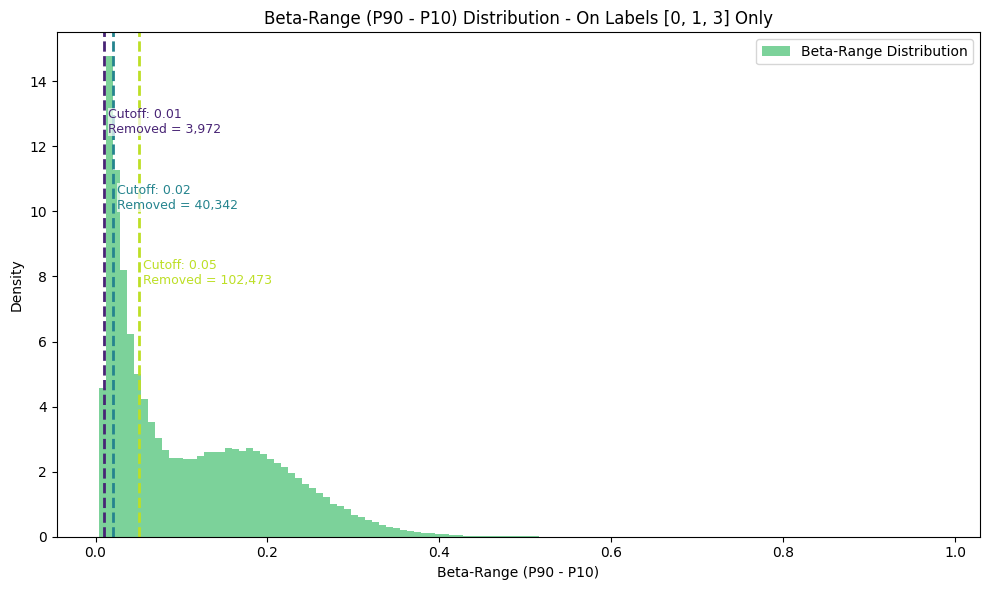


Summary: 259,211 CpGs analyzed on labels [0, 1, 3]. Final threshold applied = 0.01.
Variable 'GSE69914_varFilt' (LazyFrame) is ready for the next step.


In [9]:
# === Optimized Non-variable CpG filtering (Polars, wide matrix, fast) ===
#
# GOALS (as requested):
# 1. Run the analysis (study, filter, plot) only on the subset of labels [0, 1, 3].
# 2. Calculate the beta-range (P90 - P10) for each CpG in *one single pass*.
# 3. Study the thresholds [0.01, 0.02, 0.05] to justify the choice.
# 4. Apply the chosen filter (e.g., 0.01) to create the new filtered LazyFrame.
# 5. Create a final plot with the histogram and all 3 threshold annotations.

# ---------------- CONFIGURATION (as requested) ---------------------------
LABEL_COL       = "label"             # Column used for the subset
LABEL_FILTER    = [0, 1, 3]           # <- ACTIVE: Analysis only on these samples
THRESHOLDS      = [0.01, 0.02, 0.05]  # <- ACTIVE: For the study and plot
THRESH_TO_USE   = 0.01                # <- ACTIVE: Chosen threshold for the final filter
HIST_BINS       = 120
print(f"CONFIG: Analyzing labels={LABEL_FILTER}, Study thresholds={THRESHOLDS}")

# ---------------- 0) Prepare LazyFrame + Apply Label Subset ------------------
# Assume 'GSE69914_annot_filt' exists from a previous cell
LF0 = GSE69914_annot_filt.lazy() if isinstance(GSE69914_annot_filt, pl.DataFrame) else GSE69914_annot_filt
schema_cols = list(LF0.schema.keys())

# *** CRITICAL OPTIMIZATION: Filter *before* computing ***
# Apply the label filter (if the column exists)
if (LABEL_COL in schema_cols) and (LABEL_FILTER is not None):
    LF = LF0.filter(pl.col(LABEL_COL).is_in(LABEL_FILTER))
    print(f"Filter applied: {len(LABEL_FILTER)} labels selected.")
else:
    LF = LF0
    if LABEL_FILTER is None:
        print("WARNING: No label filter applied. Analysis on the full dataset will be extremely SLOW.")
    else:
        print("No label filter applied (column not found).")

# Identify CpG columns and metadata columns (e.g., id, label)
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
meta_cols = [c for c in schema_cols if c not in cpg_cols]
if not cpg_cols:
    raise ValueError("No CpG columns found (expected 'cg' or 'ch' prefixes).")

print(f"Found {len(cpg_cols):,} CpG columns to analyze.")

# ---------------- 1) Calculate Beta-Range (P90-P10) - OPTIMIZED (1 pass) --
# This calculation now runs ONLY on the filtered rows (e.g., labels 0,1,3)
# and will be very fast.
print("Starting beta-range (P90 - P10) calculation in 1 pass...")

# Build one expression for *each* CpG column
# This calculates (q90 - q10) per column, all in parallel
beta_range_exprs = [
    (pl.col(c).quantile(0.90) - pl.col(c).quantile(0.10)).alias(c)
    for c in cpg_cols
]

# Execute the single (and now fast) computation
# The result is a DataFrame (1 row x N CpGs) with the beta-range values
try:
    beta_range_df = LF.select(beta_range_exprs).collect(streaming=True)
except Exception:
    beta_range_df = LF.select(beta_range_exprs).collect()

# Convert to a NumPy array for fast stats and plotting
# The column order is preserved
beta_range = beta_range_df.to_numpy()[0, :]

print("Beta-range calculation complete.")

# ---------------- 2) Preliminary Study (Justification) -------------------
print("\n=== Preliminary Study (beta-range < threshold) ===")
n_total = beta_range.size
removed_counts = {} # Dictionary to save counts for the plot

for t in THRESHOLDS:
    cnt = int(np.sum(beta_range < t))
    removed_counts[t] = cnt
    print(f"  Threshold t = {t:.2f}: Removes {cnt:10,} / {n_total:,} CpGs ({cnt/n_total:6.1%})")

# ---------------- 3) Apply the Chosen Threshold ------------------------------
mask_keep = beta_range >= THRESH_TO_USE
keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
remove_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}

# Build the final filtered LazyFrame (keeps meta_cols + filtered CpGs)
LF_var = LF.select(meta_cols + sorted(list(keep_cpgs)))

# Save artifacts
pl.DataFrame({"CpG_removed": sorted(remove_cpgs)}).write_csv("cpg_removed_nonvariable.csv")
print(f"\nApplied threshold t = {THRESH_TO_USE:.2f} → Removed {len(remove_cpgs):,} CpGs; Kept {len(keep_cpgs):,} CpGs.")
print("Saved: cpg_removed_nonvariable.csv")

# Expose the filtered LazyFrame for downstream steps
GSE69914_varFilt = LF_var

# ---------------- 4) Final Plot (as requested) -----------------------
print("Generating plot...")
cmap = plt.cm.get_cmap("viridis")
hist_color = cmap(0.70)

plt.figure(figsize=(10, 6)) # Made slightly larger for labels
plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7, color=hist_color, label="Beta-Range Distribution")

# Vertical lines for the 3 thresholds
y_top, y_idx = plt.ylim()[1], 0.85
colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

for t, color in zip(THRESHOLDS, colors):
    removed = removed_counts[t]
    
    # Label as requested
    label_text = f"Cutoff: {t:.2f}\nRemoved = {removed:,}"
    
    plt.axvline(t, linestyle="--", linewidth=2, color=color)
    plt.text(t + 0.005, y_top * y_idx, label_text, fontsize=9, color=color,
             ha='left', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.2))
    y_idx -= 0.15 # Move the next label down

plt.title(f"Beta-Range (P90 - P10) Distribution - On Labels {LABEL_FILTER} Only")
plt.xlabel("Beta-Range (P90 - P10)")
plt.ylabel("Density")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("beta_range_distribution_study.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------- 5) Summary ---------------------------------------------
subset_info = f"on labels {LABEL_FILTER}" if (LABEL_FILTER is not None and LABEL_COL in schema_cols) else "on ALL samples"
print(f"\nSummary: {n_total:,} CpGs analyzed {subset_info}. Final threshold applied = {THRESH_TO_USE:.2f}.")
print("Variable 'GSE69914_varFilt' (LazyFrame) is ready for the next step.")


In [11]:
# ============================================================
# === Rebuild GSE69914_varFilt with THRESH_TO_USE = 0.05 ====
# ============================================================
THRESH_TO_USE_NEW = 0.05
print(f"\nRecomputing final filtered LazyFrame with threshold = {THRESH_TO_USE_NEW:.2f}")

# Mask: keep CpGs whose beta-range >= 0.05
mask_keep_new = beta_range >= THRESH_TO_USE_NEW
keep_cpgs_new = {cpg_cols[i] for i, keep in enumerate(mask_keep_new) if keep}
remove_cpgs_new = {cpg_cols[i] for i, keep in enumerate(mask_keep_new) if not keep}

# Build new filtered LazyFrame
GSE69914_varFilt = LF.select(meta_cols + sorted(list(keep_cpgs_new)))

# Save list of removed CpGs
pl.DataFrame({"CpG_removed": sorted(remove_cpgs_new)}).write_csv("cpg_removed_nonvariable_005.csv")

print(f"Applied threshold t = {THRESH_TO_USE_NEW:.2f} → Removed {len(remove_cpgs_new):,} CpGs; Kept {len(keep_cpgs_new):,} CpGs.")
print("Saved: cpg_removed_nonvariable_005.csv")
print("✅ Variable 'GSE69914_varFilt' updated (threshold 0.05).")



Recomputing final filtered LazyFrame with threshold = 0.05
Applied threshold t = 0.05 → Removed 102,473 CpGs; Kept 156,738 CpGs.
Saved: cpg_removed_nonvariable_005.csv
✅ Variable 'GSE69914_varFilt' updated (threshold 0.05).


In [13]:
n_rows = GSE69914_varFilt.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
n_cols = len(GSE69914_varFilt.columns)
print(f"- Dimensions: ({n_rows:,}, {n_cols:,}) → samples × CpG loci")


- Dimensions: (99, 156,740) → samples × CpG loci


## 6. Transformation to M-values

In [ ]:
# usa GSE69914_varFilt per convertire  e poi salva in formato parquet

Tumor sample for Fig.1–2: GSM1712367
Normal sample for Fig.1–2: GSM1712369


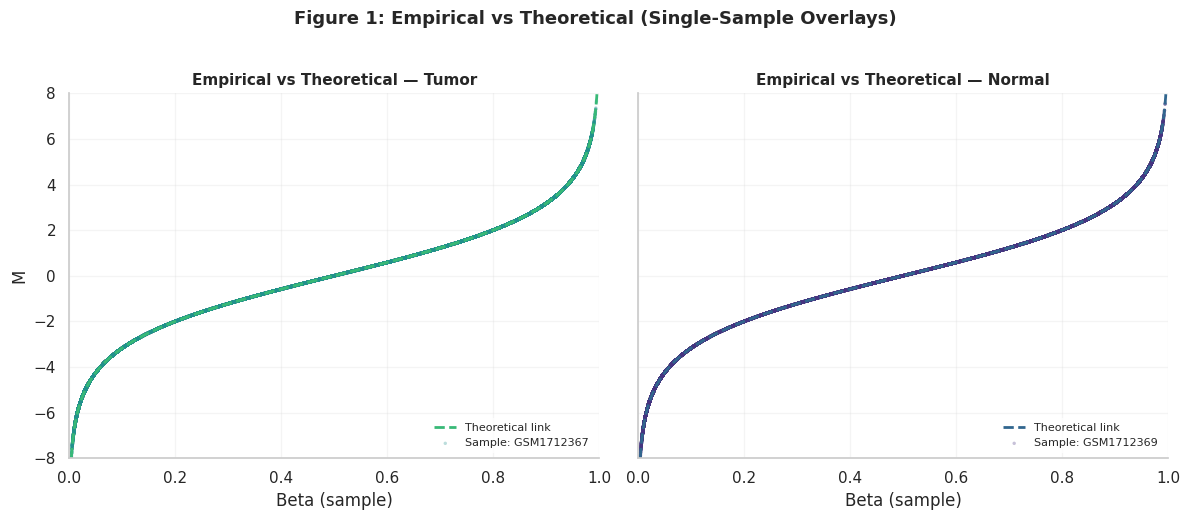

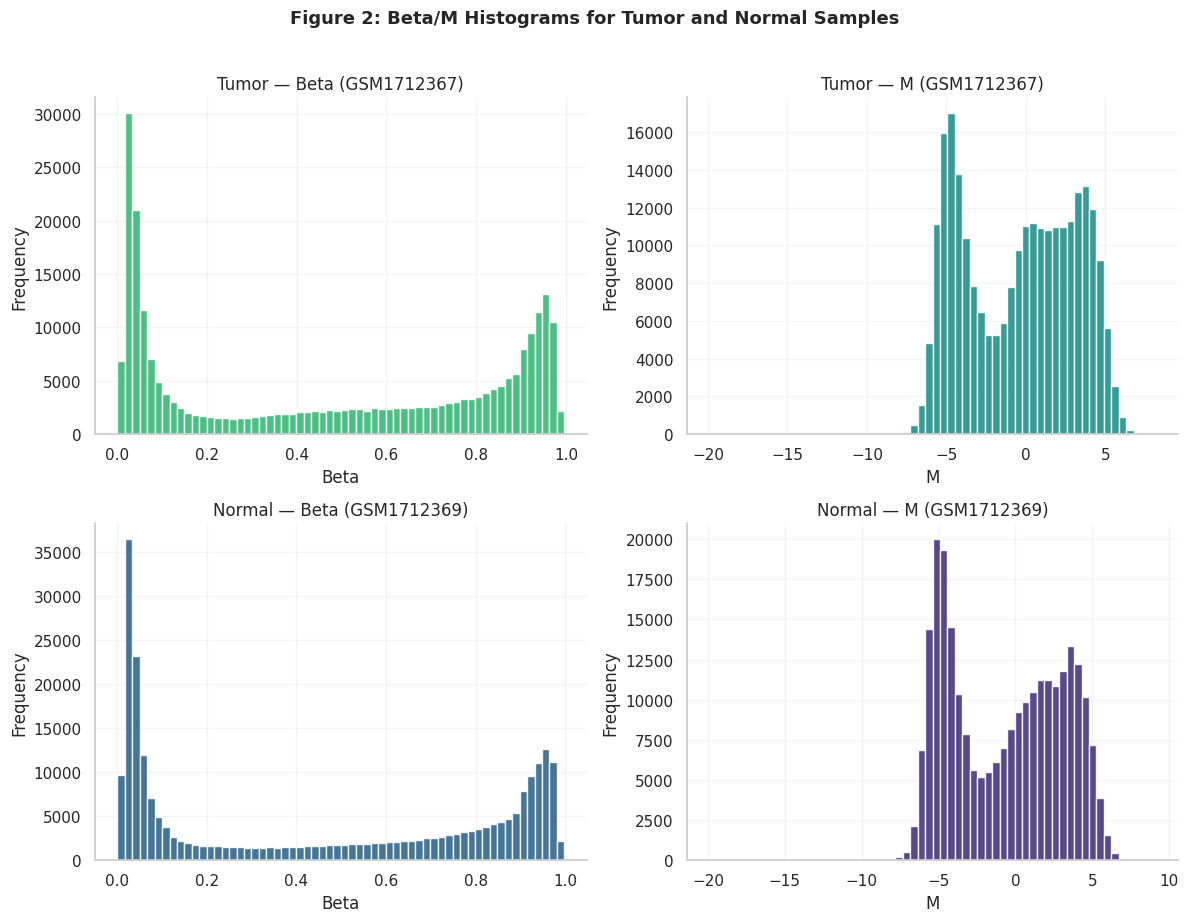

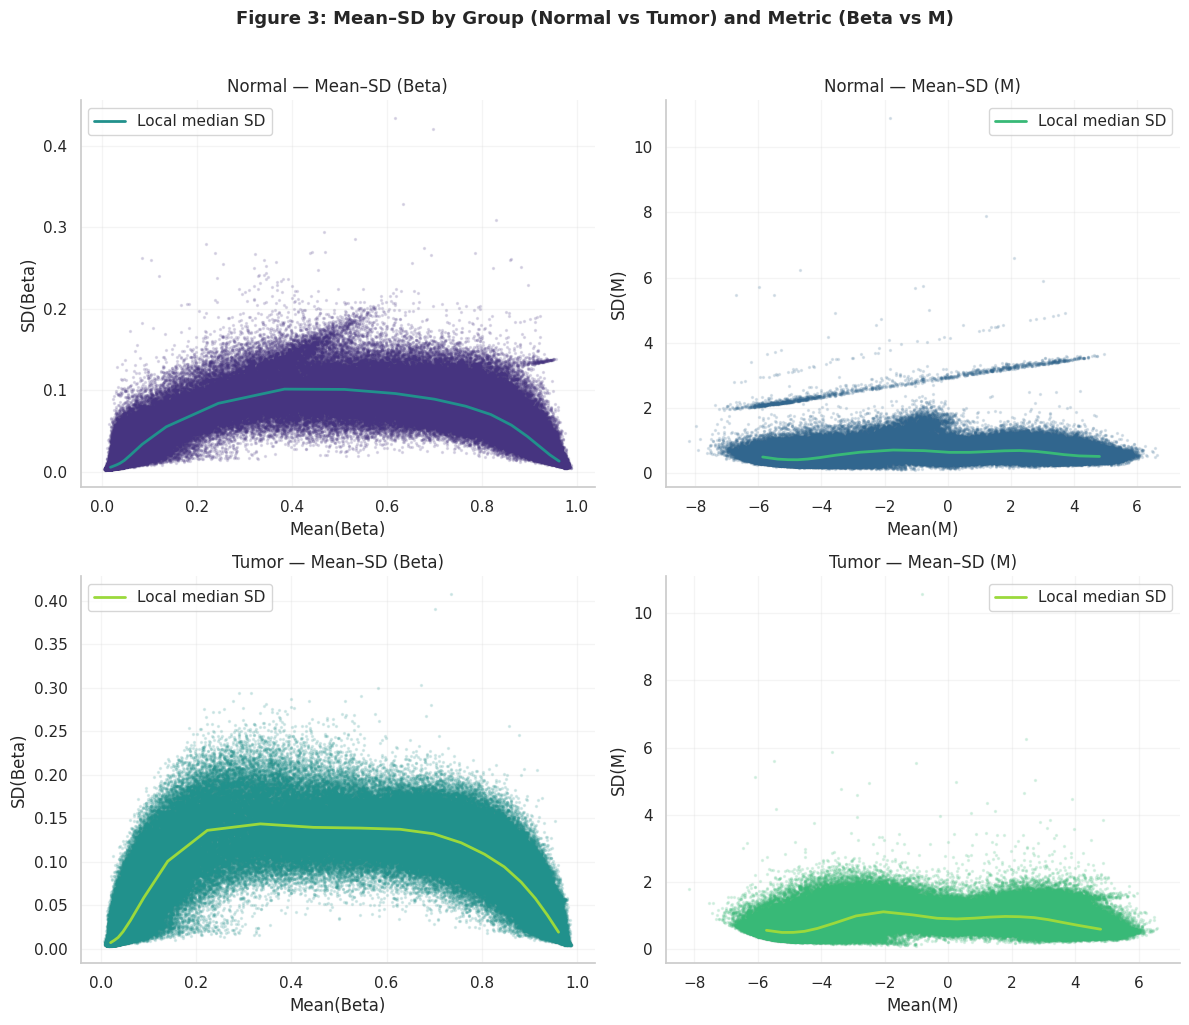

Saved figures:
 - fig1_empirical_vs_theoretical_dual.png
 - fig2_histograms_dual.png
 - fig3_mean_sd_bygroup.png


In [22]:
# UNIFIED PLOTTING PIPELINE (POLARS + PANDAS) on GSE69914_varFilt 

# -------------------- Plot defaults --------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["grid.alpha"] = 0.2
plt.rcParams["font.size"] = 10
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.facecolor"] = "white"
viridis = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
cmap = plt.cm.viridis

EPS = 1e-6  # numeric stability for Beta->M

def log2(x):
    return np.log(x) / np.log(2.0)

def compute_M_numpy(beta_vec, eps=EPS):
    b = np.clip(beta_vec.astype(float), eps, 1.0 - eps)
    return log2(b / (1.0 - b))

def compute_M_expr(col, eps=EPS):
    b = pl.col(col).cast(pl.Float64).clip(eps, 1.0 - eps)
    return (b.log() - (1.0 - b).log()) / np.log(2.0)


# -------------------- Access LazyFrame --------------------
LF = GSE69914_varFilt if isinstance(GSE69914_varFilt, pl.LazyFrame) else GSE69914_varFilt.lazy()
schema_cols = list(LF.schema.keys())
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
meta_cols = [c for c in ("id_tissue", "label") if c in schema_cols]
assert "label" in meta_cols, "Expected a 'label' column in GSE69914_varFilt."

# -------------------- Labels & sample picking --------------------
# Get one tumor (label==2) and one normal (label==0) id_tissue for single-sample plots
labels_df = LF.select(["id_tissue", "label"]).collect()
tumor_sample = labels_df.filter(pl.col("label") == 2)["id_tissue"].to_list()
tumor_sample = tumor_sample[0] if tumor_sample else None

normal_sample = labels_df.filter(pl.col("label") == 0)["id_tissue"].to_list()
normal_sample = normal_sample[0] if normal_sample else None

print("Tumor sample for Fig.1–2:", tumor_sample)
print("Normal sample for Fig.1–2:", normal_sample)

# -------------------- Materialize single-sample rows (minimal) --------------------
def get_sample_row(sample_id):
    """Return a pandas Series (CpG values) for the given sample_id, or None."""
    if sample_id is None:
        return None
    df = (
        LF.filter(pl.col("id_tissue") == sample_id)
          .select(cpg_cols)           # only CpG columns
          .collect()
    )
    if df.height == 0:
        return None
    # Evita to_pandas(index=...) che non esiste; prendo il vettore e ricostruisco la Series
    vals = df.to_numpy().ravel()
    return pd.Series(vals, index=cpg_cols, name=sample_id)


betas_tumor  = get_sample_row(tumor_sample)
betas_normal = get_sample_row(normal_sample)

# Build Beta/M matrices (only for those one-sample vectors)
Ms_tumor  = compute_M_numpy(betas_tumor.values)  if betas_tumor  is not None else None
Ms_normal = compute_M_numpy(betas_normal.values) if betas_normal is not None else None

# -------------------- FIGURE 1: Empirical vs Theoretical (Single Samples) --------------------
def figure1_empirical_vs_theoretical_dual_single(betas_tumor, betas_normal,
                                                 M_tumor, M_normal,
                                                 tumor_id, normal_id,
                                                 max_points=80000, m_lim=(-8, 8)):
    sns.set_style("whitegrid")
    m_grid = np.linspace(m_lim[0], m_lim[1], 2000)
    beta_curve = (2.0 ** m_grid) / (1.0 + 2.0 ** m_grid)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    def _panel(ax, bvals, mvals, sample_name, title_suffix, color_curve, color_scatter):
        if bvals is None or mvals is None:
            ax.axis("off"); return
        n = len(bvals)
        if n > max_points:
            idx = np.random.choice(n, size=max_points, replace=False)
            bvals = bvals[idx]
            mvals = mvals[idx]

        ax.plot(beta_curve, m_grid, linewidth=2, linestyle='--',
                color=color_curve, label="Theoretical link")
        ax.scatter(bvals, mvals, s=6, alpha=0.3, color=color_scatter,
                   edgecolors='none', label=f"Sample: {sample_name}")
        ax.set_xlim(0, 1)
        ax.set_ylim(*m_lim)
        ax.set_xlabel("Beta (sample)")
        ax.set_title(f"Empirical vs Theoretical — {title_suffix}",
                     fontsize=11, weight='semibold')
        ax.legend(loc="lower right", fontsize=8, frameon=True,
                  facecolor='white', edgecolor='none')

    _panel(axes[0], betas_tumor.values if betas_tumor is not None else None,
           M_tumor, tumor_id, "Tumor", viridis[3], viridis[2])
    axes[0].set_ylabel("M")

    _panel(axes[1], betas_normal.values if betas_normal is not None else None,
           M_normal, normal_id, "Normal", viridis[1], viridis[0])

    fig.suptitle("Figure 1: Empirical vs Theoretical (Single-Sample Overlays)",
                 fontsize=13, y=1.03, weight='bold')
    fig.tight_layout()
    sns.despine()
    plt.savefig("fig1_empirical_vs_theoretical_dual.png", dpi=300, bbox_inches="tight")
    plt.show()

figure1_empirical_vs_theoretical_dual_single(
    betas_tumor, betas_normal, Ms_tumor, Ms_normal, tumor_sample, normal_sample,
    max_points=80000, m_lim=(-8, 8)
)

# -------------------- FIGURE 2: Histograms (Single Samples) --------------------
def figure2_histograms_dual_single(betas_tumor, betas_normal, M_tumor, M_normal,
                                   tumor_id, normal_id, bins=60):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    def _hist(ax, data, title, xlabel, color):
        if data is None:
            ax.axis("off"); return
        ax.hist(data, bins=bins, alpha=0.9, color=color, edgecolor='white')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")

    _hist(axes[0, 0], betas_tumor.values if betas_tumor is not None else None,
          f"Tumor — Beta ({tumor_id})", "Beta", viridis[3])
    _hist(axes[0, 1], M_tumor, f"Tumor — M ({tumor_id})", "M", viridis[2])
    _hist(axes[1, 0], betas_normal.values if betas_normal is not None else None,
          f"Normal — Beta ({normal_id})", "Beta", viridis[1])
    _hist(axes[1, 1], M_normal, f"Normal — M ({normal_id})", "M", viridis[0])

    fig.suptitle("Figure 2: Beta/M Histograms for Tumor and Normal Samples",
                 fontsize=13, y=1.02, weight='bold')
    fig.tight_layout()
    sns.despine()
    plt.savefig("fig2_histograms_dual.png", dpi=300, bbox_inches="tight")
    plt.show()

figure2_histograms_dual_single(
    betas_tumor, betas_normal, Ms_tumor, Ms_normal, tumor_sample, normal_sample, bins=60
)

# -------------------- FIGURE 3: Mean–SD by Group (Normal vs Tumor) and Metric (Beta vs M) --------------------
def compute_group_mean_sd_polars(LF, cpg_cols, label_value, metric="beta", eps=EPS):
    """Returns (mean_vec, sd_vec) for all CpGs within label==label_value, for the chosen metric."""
    subset = LF.filter(pl.col("label") == pl.lit(label_value))
    if metric == "beta":
        mean_exprs = [pl.col(c).mean().alias(c) for c in cpg_cols]
        sd_exprs   = [pl.col(c).std(ddof=1).alias(c)  for c in cpg_cols]
        mean_row = subset.select(mean_exprs).collect()
        sd_row   = subset.select(sd_exprs).collect()
    elif metric == "m":
        # Compute M on-the-fly per column
        M_mean_exprs = [(compute_M_expr(c, eps=eps)).mean().alias(c) for c in cpg_cols]
        M_sd_exprs   = [(compute_M_expr(c, eps=eps)).std(ddof=1).alias(c)  for c in cpg_cols]
        mean_row = subset.select(M_mean_exprs).collect()
        sd_row   = subset.select(M_sd_exprs).collect()
    else:
        raise ValueError("metric must be 'beta' or 'm'")
    mean_vec = mean_row.to_numpy().ravel()
    sd_vec   = sd_row.to_numpy().ravel()
    return mean_vec, sd_vec

def _binned_median_sd(means, sds, n_bins=20):
    df = pd.DataFrame({"mean": means, "sd": sds}).dropna().sort_values("mean")
    if len(df) == 0:
        return np.array([]), np.array([])
    bins = np.array_split(df, n_bins)
    x = [b["mean"].median() for b in bins if len(b)]
    y = [b["sd"].median() for b in bins if len(b)]
    return np.array(x), np.array(y)

def figure3_mean_sd_bygroup_polars(LF, cpg_cols, n_bins=20):
    # Normal (0) vs Tumor (2), Beta and M
    nb_mean, nb_sd = compute_group_mean_sd_polars(LF, cpg_cols, label_value=0, metric="beta")
    nm_mean, nm_sd = compute_group_mean_sd_polars(LF, cpg_cols, label_value=0, metric="m")
    tb_mean, tb_sd = compute_group_mean_sd_polars(LF, cpg_cols, label_value=2, metric="beta")
    tm_mean, tm_sd = compute_group_mean_sd_polars(LF, cpg_cols, label_value=2, metric="m")

    nxb, nyb = _binned_median_sd(nb_mean, nb_sd, n_bins=n_bins)
    nxm, nym = _binned_median_sd(nm_mean, nm_sd, n_bins=n_bins)
    txb, tyb = _binned_median_sd(tb_mean, tb_sd, n_bins=n_bins)
    txm, tym = _binned_median_sd(tm_mean, tm_sd, n_bins=n_bins)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    def _scatter(ax, mean, sd, xb, yb, title, xlabel, ylabel, color_points, color_line):
        ax.scatter(mean, sd, s=2, alpha=0.15, color=color_points)
        if len(xb) and len(yb):
            ax.plot(xb, yb, linewidth=2, label="Local median SD", color=color_line)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend()

    _scatter(axes[0, 0], nb_mean, nb_sd, nxb, nyb, "Normal — Mean–SD (Beta)",
             "Mean(Beta)", "SD(Beta)", viridis[0], viridis[2])
    _scatter(axes[0, 1], nm_mean, nm_sd, nxm, nym, "Normal — Mean–SD (M)",
             "Mean(M)", "SD(M)", viridis[1], viridis[3])
    _scatter(axes[1, 0], tb_mean, tb_sd, txb, tyb, "Tumor — Mean–SD (Beta)",
             "Mean(Beta)", "SD(Beta)", viridis[2], viridis[4])
    _scatter(axes[1, 1], tm_mean, tm_sd, txm, tym, "Tumor — Mean–SD (M)",
             "Mean(M)", "SD(M)", viridis[3], viridis[4])

    fig.suptitle("Figure 3: Mean–SD by Group (Normal vs Tumor) and Metric (Beta vs M)",
                 fontsize=13, y=1.02, weight='bold')
    fig.tight_layout()
    sns.despine()
    plt.savefig("fig3_mean_sd_bygroup.png", dpi=300, bbox_inches="tight")
    plt.show()

figure3_mean_sd_bygroup_polars(LF, cpg_cols, n_bins=20)

print("Saved figures:")
print(" - fig1_empirical_vs_theoretical_dual.png")
print(" - fig2_histograms_dual.png")
print(" - fig3_mean_sd_bygroup.png")


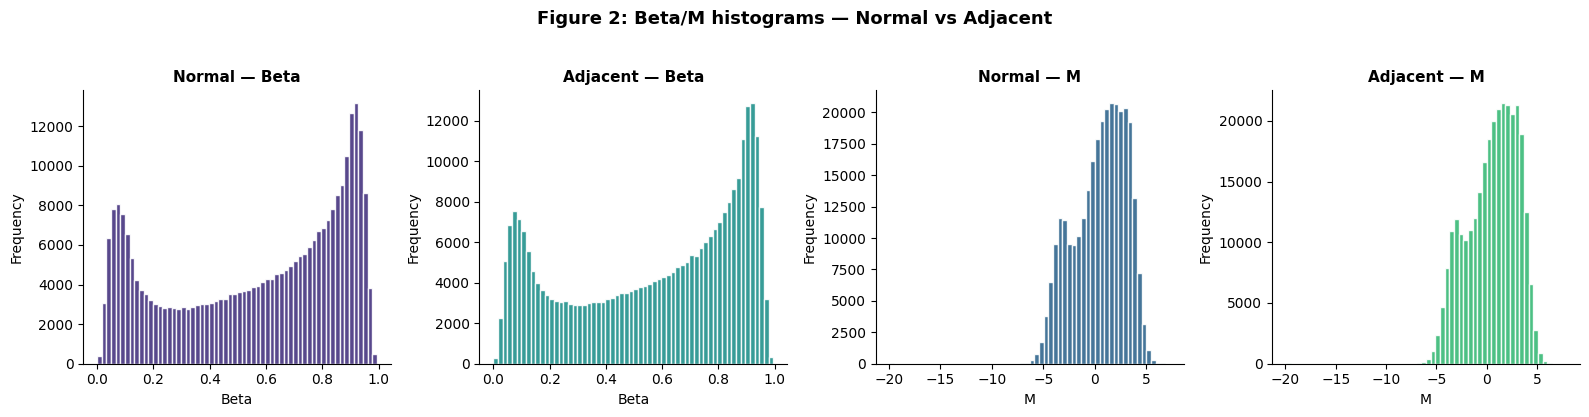

✅ Saved: fig2_norm_vs_adj_row.png


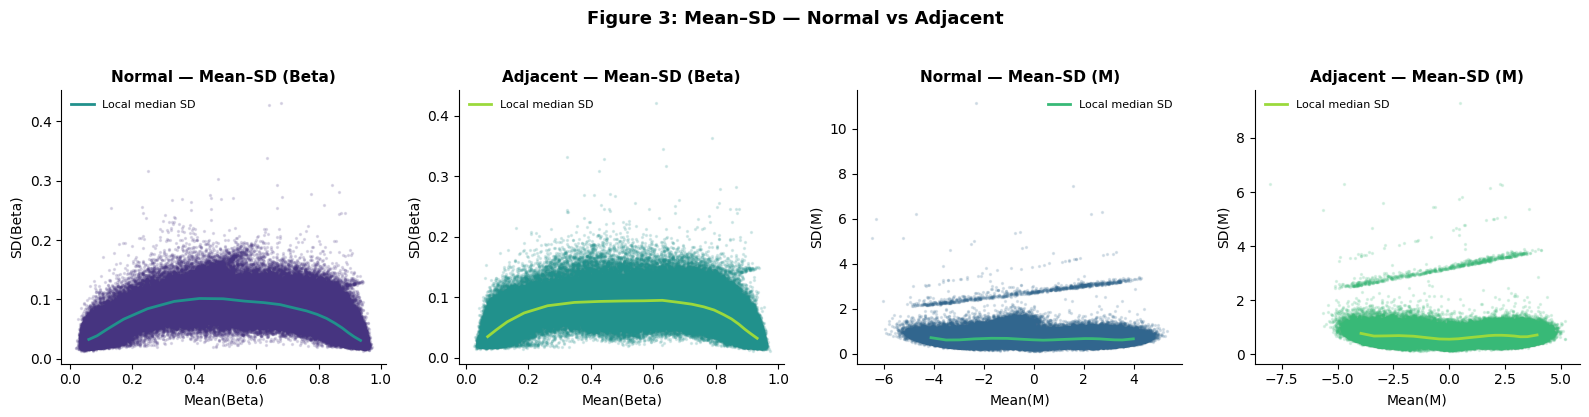

✅ Saved: fig3_norm_vs_adj_row.png


In [20]:
# =========================================
# SETTINGS: gruppi per questo studio
# =========================================
NORMAL_LABELS   = [0, 3]
ADJACENT_LABELS = [1]
viridis = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
cmap = plt.cm.viridis

# -------------------- Helpers --------------------
def collect_group_betas(LF, cpg_cols, label_set, max_points=300_000, seed=42):
    """
    Raccoglie tutti i β (tutte le CpG x tutti i campioni) per i label in label_set.
    Restituisce un array 1D; opzionalmente sottocampiona per velocizzare i plot.
    """
    df = (
        LF.filter(pl.col("label").is_in(label_set))
          .select(cpg_cols)
          .collect()
    )
    arr = df.to_numpy().astype(np.float32, copy=False).ravel()
    arr = arr[np.isfinite(arr)]
    if (max_points is not None) and (arr.size > max_points):
        rng = np.random.default_rng(seed)
        idx = rng.choice(arr.size, size=max_points, replace=False)
        arr = arr[idx]
    return arr

def log2(x):
    return np.log(x) / np.log(2.0)

def compute_M_numpy(beta_vec, eps=EPS):
    b = np.clip(beta_vec.astype(float), eps, 1.0 - eps)
    return log2(b / (1.0 - b))

# ============================
# FIGURE 2: Hist su una riga [β_norm, β_adj, M_norm, M_adj]
# ============================
def figure2_histograms_norm_vs_adj_row(LF, cpg_cols, bins=60, max_points=300_000):
    beta_norm = collect_group_betas(LF, cpg_cols, NORMAL_LABELS, max_points=max_points)
    beta_adj  = collect_group_betas(LF, cpg_cols, ADJACENT_LABELS, max_points=max_points)
    M_norm = compute_M_numpy(beta_norm) if beta_norm.size else None
    M_adj  = compute_M_numpy(beta_adj)  if beta_adj.size  else None

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    def _hist(ax, data, title, xlabel, color):
        if data is None or len(data) == 0:
            ax.axis("off"); return
        ax.hist(data, bins=bins, alpha=0.9, color=color, edgecolor='white')
        ax.set_title(title, fontsize=11, weight='semibold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")

    _hist(axes[0], beta_norm, "Normal — Beta", "Beta", viridis[0])
    _hist(axes[1], beta_adj,  "Adjacent — Beta",  "Beta", viridis[2])
    _hist(axes[2], M_norm,    "Normal — M",    "M",    viridis[1])
    _hist(axes[3], M_adj,     "Adjacent — M",     "M",    viridis[3])

    fig.suptitle("Figure 2: Beta/M histograms — Normal vs Adjacent", y=1.03, fontsize=13, weight='bold')
    fig.tight_layout()
    sns.despine()
    plt.savefig("fig2_norm_vs_adj_row.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ Saved: fig2_norm_vs_adj_row.png")

# ============================
# FIGURE 3: Mean–SD su una riga [β_norm, β_adj, M_norm, M_adj]
# ============================
def compute_group_mean_sd_polars_multi(LF, cpg_cols, label_values, metric="beta", eps=EPS):
    """(mean_vec, sd_vec) per CpG su tutti i campioni con label in label_values."""
    subset = LF.filter(pl.col("label").is_in(label_values))
    if metric == "beta":
        mean_exprs = [pl.col(c).mean().alias(c) for c in cpg_cols]
        sd_exprs   = [pl.col(c).std(ddof=1).alias(c)  for c in cpg_cols]
        mean_row = subset.select(mean_exprs).collect()
        sd_row   = subset.select(sd_exprs).collect()
    elif metric == "m":
        M_mean_exprs = [(compute_M_expr(c, eps=eps)).mean().alias(c) for c in cpg_cols]
        M_sd_exprs   = [(compute_M_expr(c, eps=eps)).std(ddof=1).alias(c)  for c in cpg_cols]
        mean_row = subset.select(M_mean_exprs).collect()
        sd_row   = subset.select(M_sd_exprs).collect()
    else:
        raise ValueError("metric must be 'beta' or 'm'")
    return mean_row.to_numpy().ravel(), sd_row.to_numpy().ravel()

def _binned_median_sd(means, sds, n_bins=20):
    df = pd.DataFrame({"mean": means, "sd": sds}).dropna().sort_values("mean")
    if len(df) == 0:
        return np.array([]), np.array([])
    bins = np.array_split(df, n_bins)
    x = [b["mean"].median() for b in bins if len(b)]
    y = [b["sd"].median() for b in bins if len(b)]
    return np.array(x), np.array(y)

def figure3_mean_sd_norm_vs_adj_row(LF, cpg_cols, n_bins=20):
    # Normal = {0,3}; Adjacent = {1}; metriche: beta, m
    nb_mean, nb_sd = compute_group_mean_sd_polars_multi(LF, cpg_cols, NORMAL_LABELS, metric="beta")
    nm_mean, nm_sd = compute_group_mean_sd_polars_multi(LF, cpg_cols, NORMAL_LABELS, metric="m")
    ab_mean, ab_sd = compute_group_mean_sd_polars_multi(LF, cpg_cols, ADJACENT_LABELS, metric="beta")
    am_mean, am_sd = compute_group_mean_sd_polars_multi(LF, cpg_cols, ADJACENT_LABELS, metric="m")

    nxb, nyb = _binned_median_sd(nb_mean, nb_sd, n_bins=n_bins)
    nxm, nym = _binned_median_sd(nm_mean, nm_sd, n_bins=n_bins)
    axb, ayb = _binned_median_sd(ab_mean, ab_sd, n_bins=n_bins)
    axm, aym = _binned_median_sd(am_mean, am_sd, n_bins=n_bins)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    def _scatter(ax, mean, sd, xb, yb, title, xlabel, ylabel, color_points, color_line):
        ax.scatter(mean, sd, s=2, alpha=0.15, color=color_points)
        if len(xb) and len(yb):
            ax.plot(xb, yb, linewidth=2, label="Local median SD", color=color_line)
        ax.set_title(title, fontsize=11, weight='semibold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(loc="best", fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    _scatter(axes[0], nb_mean, nb_sd, nxb, nyb,
             "Normal — Mean–SD (Beta)", "Mean(Beta)", "SD(Beta)", viridis[0], viridis[2])
    _scatter(axes[1], ab_mean, ab_sd, axb, ayb,
             "Adjacent — Mean–SD (Beta)",  "Mean(Beta)", "SD(Beta)", viridis[2], viridis[4])
    _scatter(axes[2], nm_mean, nm_sd, nxm, nym,
             "Normal — Mean–SD (M)",    "Mean(M)", "SD(M)", viridis[1], viridis[3])
    _scatter(axes[3], am_mean, am_sd, axm, aym,
             "Adjacent — Mean–SD (M)",     "Mean(M)", "SD(M)", viridis[3], viridis[4])

    fig.suptitle("Figure 3: Mean–SD — Normal vs Adjacent", y=1.03, fontsize=13, weight='bold')
    fig.tight_layout()
    sns.despine()
    plt.savefig("fig3_norm_vs_adj_row.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ Saved: fig3_norm_vs_adj_row.png")

# ============================
# Esegui i plot
# ============================
figure2_histograms_norm_vs_adj_row(GSE69914_varFilt, cpg_cols, bins=60, max_points=300_000)
figure3_mean_sd_norm_vs_adj_row(GSE69914_varFilt, cpg_cols, n_bins=20)


In [14]:
# ============================
# β → M on GSE69914_varFilt
# ============================
import polars as pl
import numpy as np
import os

EPS = 1e-6  # numeric stability for Beta->M
OUT_PAR_M = "/kaggle/working/GSE69914_M_values_lz4.parquet"  # cambia se vuoi

# 1) Access LazyFrame e colonne
LF_beta = GSE69914_varFilt if isinstance(GSE69914_varFilt, pl.LazyFrame) else GSE69914_varFilt.lazy()
schema_cols = list(LF_beta.schema.keys())
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
meta_cols = [c for c in ("id_tissue", "label") if c in schema_cols]
assert "label" in meta_cols and "id_tissue" in meta_cols, "Mi aspetto 'id_tissue' e 'label' in GSE69914_varFilt."
assert len(cpg_cols) > 0, "Non ho trovato colonne CpG."

# 2) Definisci l'espressione β→M (base 2), con clip per stabilità, cast a float32
def compute_M_expr(col, eps=EPS):
    b = pl.col(col).cast(pl.Float64).clip(eps, 1.0 - eps)
    return ((b.log() - (1.0 - b).log()) / np.log(2.0)).cast(pl.Float32)

m_exprs = [compute_M_expr(c).alias(c) for c in cpg_cols]

# 3) Costruisci il LazyFrame M-values (stessi nomi CpG, meta invariati)
GSE69914_M_values = LF_beta.with_columns(m_exprs)

# 4) Salva in Parquet (LZ4), preferendo sink_parquet per non materializzare in RAM
try:
    GSE69914_M_values.sink_parquet(OUT_PAR_M, compression="lz4", maintain_order=True)
except Exception as e:
    # fallback: materializza e salva
    df_m = GSE69914_M_values.collect(streaming=True)
    df_m.write_parquet(OUT_PAR_M, compression="lz4")
    del df_m

print(f"✅ Parquet (M-values) salvato: {OUT_PAR_M}")
print("✅ Variabile pronta: GSE69914_M_values (LazyFrame con M-values)")


✅ Parquet (M-values) salvato: /kaggle/working/GSE69914_M_values_lz4.parquet
✅ Variabile pronta: GSE69914_M_values (LazyFrame con M-values)


In [15]:
n_rows = GSE69914_M_values.select(pl.len().alias("rows")).collect(streaming=True)["rows"][0]
n_cols = len(GSE69914_M_values.columns)
print(f"- Dimensions: ({n_rows:,}, {n_cols:,}) → samples × CpG loci")


- Dimensions: (99, 156,740) → samples × CpG loci


## 7. Batch-Effect Correction
è da fare? serve? boh

## 8. Preliminary Statistical Filters
cosa c'è da fare ancora non si sa..

## 9. Correlation Pruning
è da fare? si vedrà

## 10. Feature Standardization for Machine Learning
cosa c'è da fare?

## 11. Controllare se Nastaran ha fatto roba in più

### 12. Capire che cromosomi bisogna usare

## END. Quali cromosomi ci sono rimastri dopo tutta questa scrematura?